# 02 · Behavioral evaluation & nulls

Score a behavioral task and, crucially, compare against matched null floors. A score that does not clear chance and a random-feature readout is reporting noise.

**Scope caveat:** this is an illustrative null-interpretation companion, not a UMI model-registration or scoring quickstart. It deliberately uses deterministic synthetic probabilities so the statistical lesson is laptop-safe and download-free. Use notebook 01 or `../docs/getting_started.md` for the public `load_model` / `score` workflow; production ROAR scoring is EC2-only.


In [1]:
import numpy as np

labels = np.array(['real', 'pseudo', 'real', 'pseudo', 'real', 'pseudo'])
probabilities = {
    'chance-baseline': np.tile([0.50, 0.50], (len(labels), 1)),
    'random-vit-b-32': np.array([
        [0.54, 0.46], [0.49, 0.51], [0.52, 0.48],
        [0.47, 0.53], [0.51, 0.49], [0.50, 0.50],
    ]),
    'toy-trained-readout': np.array([
        [0.88, 0.12], [0.18, 0.82], [0.81, 0.19],
        [0.22, 0.78], [0.79, 0.21], [0.15, 0.85],
    ]),
}

def balanced_accuracy(probs):
    pred = np.where(probs[:, 0] >= probs[:, 1], 'real', 'pseudo')
    per_class = []
    for label in ['real', 'pseudo']:
        mask = labels == label
        per_class.append(float(np.mean(pred[mask] == labels[mask])))
    return float(np.mean(per_class))

results = {name: balanced_accuracy(probs) for name, probs in probabilities.items()}
for name, value in results.items():
    print(f'{name:20s} {value:.3f}')
print('toy-trained-readout clears both nulls:',
      results['toy-trained-readout'] > max(results['chance-baseline'], results['random-vit-b-32']))


chance-baseline      0.500
random-vit-b-32      0.833
toy-trained-readout  1.000
toy-trained-readout clears both nulls: True


## The null floors, as a bar plot with the chance line

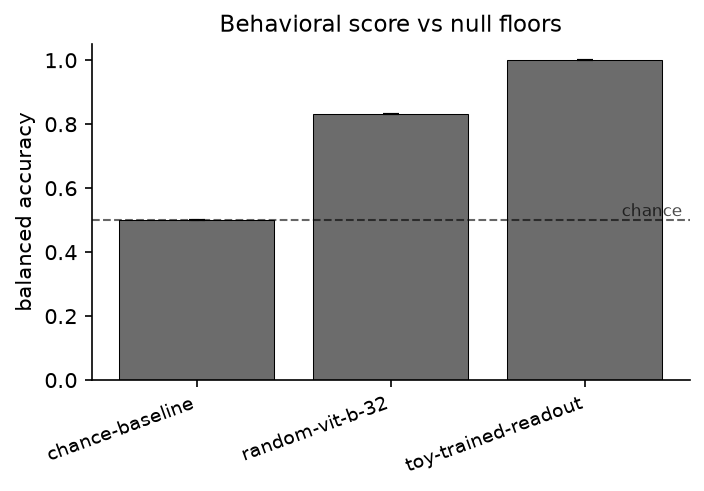

wrote plot: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/roar_nulls_demo.png


In [2]:
import warnings
warnings.filterwarnings('ignore', message='xarray subclass Score should explicitly define __slots__', category=FutureWarning)

from pathlib import Path
import tempfile
from IPython.display import Image, display
from brainscore.visualization import ablation_effect_bar

out_png = Path(tempfile.gettempdir()) / 'roar_nulls_demo.png'
ablation_effect_bar({k: (v, 0.0) for k, v in results.items()},
                    ylabel='balanced accuracy', chance=0.5,
                    title='Behavioral score vs null floors',
                    out_png=str(out_png))
display(Image(str(out_png)))
print('wrote plot:', out_png)


**Reading it:** `chance-baseline` sits at the label-balance floor; `random-vit-b-32` adds whatever a logistic readout overfits from random features; a real model must clear both. This is the discipline applied to every capability in these notebooks.